In [1]:
# ============================================
# HW10-11: Computer Vision in PyTorch
# Part A: Classification with CIFAR100
# Part B: Segmentation with OxfordIIITPet
# ============================================

# ========== 1. Импорты и настройки ==========
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split, Subset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from PIL import Image
import time
from tqdm import tqdm

# Фиксация seed для воспроизводимости
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Создание папок для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

print("Setup complete!")

Using device: cpu
Setup complete!



PART A: CIFAR100 Classification
Loading CIFAR100 dataset...


100%|██████████| 169M/169M [10:10<00:00, 277kB/s]  
/Users/elizaveta/Desktop/pactice_AIE/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Total train samples: 50000
Test samples: 10000

Split sizes:
Train: 40000
Validation: 10000
Test: 10000
Number of classes: 100

Sample batch shape: torch.Size([128, 3, 32, 32])
Sample labels shape: torch.Size([128])
Label range: 0 to 99


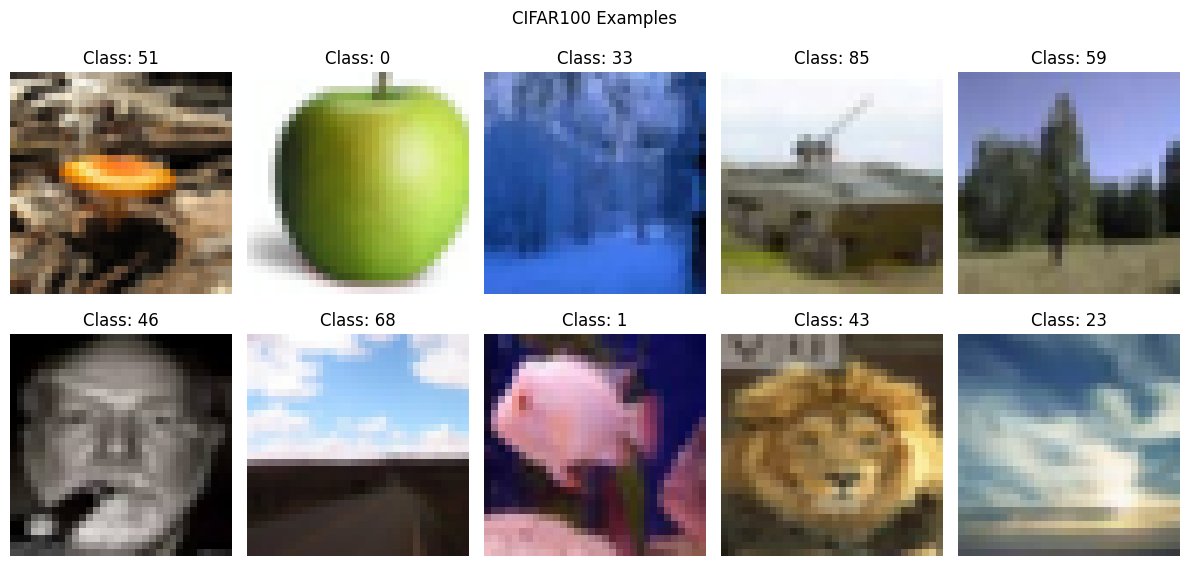

In [2]:
# ========== 2. Часть A: CIFAR100 - Загрузка данных ==========
print("\n" + "="*60)
print("PART A: CIFAR100 Classification")
print("="*60)

# Нормализация для CIFAR100
cifar_mean = [0.5071, 0.4865, 0.4409]
cifar_std = [0.2673, 0.2564, 0.2762]

# Базовые transforms (без аугментаций)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])

# Аугментации для обучения
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])

print("Loading CIFAR100 dataset...")
# Загрузка train и test
train_full = datasets.CIFAR100(
    root='./data', 
    train=True, 
    download=True,
    transform=aug_transform
)

test_dataset = datasets.CIFAR100(
    root='./data', 
    train=False, 
    download=True,
    transform=base_transform
)

print(f"Total train samples: {len(train_full)}")
print(f"Test samples: {len(test_dataset)}")

# Разделение train на train/val (80/20)
val_size = int(0.2 * len(train_full))
train_size = len(train_full) - val_size
train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

# Важно: для валидации используем базовые transforms (без аугментаций)
# Сохраняем ссылку на исходный датасет и меняем transform
val_dataset.dataset.transform = base_transform

# DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\nSplit sizes:")
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")
print(f"Number of classes: 100")

# Проверка данных
sample_batch, sample_labels = next(iter(train_loader))
print(f"\nSample batch shape: {sample_batch.shape}")
print(f"Sample labels shape: {sample_labels.shape}")
print(f"Label range: {sample_labels.min()} to {sample_labels.max()}")

# Визуализация примеров
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = sample_batch[i].permute(1, 2, 0).cpu().numpy()
    img = img * cifar_std + cifar_mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f'Class: {sample_labels[i].item()}')
    ax.axis('off')
plt.suptitle('CIFAR100 Examples')
plt.tight_layout()
plt.savefig('artifacts/figures/cifar100_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# ========== 3. Часть A: Создание моделей ==========

# 3.1 Простая CNN для CIFAR100
class SimpleCNN_CIFAR100(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        # Conv layers
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        
        # Для CIFAR100 32x32 -> после 3 пулингов: 32->16->8->4
        self.fc1 = nn.Linear(256 * 4 * 4, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 32 -> 16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 16 -> 8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 8 -> 4
        x = x.view(-1, 256 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Проверка CNN модели
model_cnn = SimpleCNN_CIFAR100(num_classes=100)
test_input = torch.randn(1, 3, 32, 32)
output = model_cnn(test_input)
print(f"CNN model output shape: {output.shape}")
print(f"CNN parameters: {sum(p.numel() for p in model_cnn.parameters()):,}")

# 3.2 ResNet18 для transfer learning
from torchvision.models import resnet18, ResNet18_Weights

def create_resnet18_cifar100(num_classes=100, freeze_backbone=True):
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = resnet18(weights=weights)
    
    if freeze_backbone:
        # Замораживаем все слои
        for param in model.parameters():
            param.requires_grad = False
    
    # Заменяем классификационную голову для CIFAR100
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    return model

# Проверка ResNet модели
model_resnet = create_resnet18_cifar100(num_classes=100, freeze_backbone=True)
print(f"\nResNet18 parameters (trainable): {sum(p.numel() for p in model_resnet.parameters() if p.requires_grad):,}")
print(f"ResNet18 total parameters: {sum(p.numel() for p in model_resnet.parameters()):,}")

CNN model output shape: torch.Size([1, 100])
CNN parameters: 5,143,140
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/elizaveta/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:10<00:00, 4.34MB/s]



ResNet18 parameters (trainable): 51,300
ResNet18 total parameters: 11,227,812


In [5]:
# ========== 4. Часть A: Функции обучения ==========

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Обучение одной эпохи"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(loader, desc='Training'):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    avg_loss = total_loss / total
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    """Оценка модели"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Evaluating'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    avg_loss = total_loss / total
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def train_model(model, train_loader, val_loader, epochs, lr, device, model_name="model"):
    """Полный цикл обучения"""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.1)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    best_val_acc = 0
    best_model_state = None
    best_epoch = 0
    
    print(f"\nTraining {model_name} for {epochs} epochs...")
    start_time = time.time()
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            best_epoch = epoch + 1
        
        scheduler.step()
    
    elapsed_time = time.time() - start_time
    print(f"\nTraining completed in {elapsed_time/60:.2f} minutes")
    print(f"Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")
    
    # Загружаем лучшую модель
    model.load_state_dict(best_model_state)
    return model, history, best_val_acc

In [6]:
# ========== 5. Часть A: Эксперимент C1 - Simple CNN без аугментаций ==========
print("\n" + "="*60)
print("EXPERIMENT C1: Simple CNN without augmentations")
print("="*60)

# Создаем датасет без аугментаций
train_full_c1 = datasets.CIFAR100(
    root='./data', train=True, download=False, transform=base_transform
)
train_dataset_c1, val_dataset_c1 = random_split(train_full_c1, [train_size, val_size])
# Для валидации используем base_transform
val_dataset_c1.dataset.transform = base_transform

train_loader_c1 = DataLoader(train_dataset_c1, batch_size=128, shuffle=True, num_workers=2)
val_loader_c1 = DataLoader(val_dataset_c1, batch_size=128, shuffle=False, num_workers=2)

model_c1 = SimpleCNN_CIFAR100(num_classes=100)
model_c1, history_c1, best_val_c1 = train_model(
    model_c1, train_loader_c1, val_loader_c1, 
    epochs=30, lr=0.001, device=device, model_name="C1 (CNN no aug)"
)

# Оценка на test
test_loss_c1, test_acc_c1 = evaluate(model_c1, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nC1 Test Accuracy: {test_acc_c1:.2f}%")


EXPERIMENT C1: Simple CNN without augmentations

Training C1 (CNN no aug) for 30 epochs...

Epoch 1/30


Evaluating: 100%|██████████| 79/79 [00:19<00:00,  4.02it/s]


Train Loss: 3.8886, Train Acc: 9.74%
Val Loss: 3.3633, Val Acc: 17.60%

Epoch 2/30


Evaluating: 100%|██████████| 79/79 [00:19<00:00,  4.03it/s]


Train Loss: 3.2236, Train Acc: 20.50%
Val Loss: 2.9106, Val Acc: 26.13%

Epoch 3/30


...

Train Loss: 0.5108, Train Acc: 83.67%
Val Loss: 2.1016, Val Acc: 52.37%

Epoch 30/30


Evaluating: 100%|██████████| 79/79 [00:18<00:00,  4.31it/s]


Train Loss: 0.5014, Train Acc: 83.86%
Val Loss: 2.1132, Val Acc: 52.31%

Training completed in 52.57 minutes
Best validation accuracy: 52.53% at epoch 20


Evaluating: 100%|██████████| 79/79 [00:18<00:00,  4.33it/s]


C1 Test Accuracy: 53.34%


In [7]:
# ========== 6. Часть A: Эксперимент C2 - Simple CNN с аугментациями ==========
print("\n" + "="*60)
print("EXPERIMENT C2: Simple CNN with augmentations")
print("="*60)

# Используем train_loader с аугментациями (уже создан)
model_c2 = SimpleCNN_CIFAR100(num_classes=100)
model_c2, history_c2, best_val_c2 = train_model(
    model_c2, train_loader, val_loader, 
    epochs=30, lr=0.001, device=device, model_name="C2 (CNN with aug)"
)

test_loss_c2, test_acc_c2 = evaluate(model_c2, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nC2 Test Accuracy: {test_acc_c2:.2f}%")


EXPERIMENT C2: Simple CNN with augmentations

Training C2 (CNN with aug) for 30 epochs...

Epoch 1/30


Evaluating: 100%|██████████| 79/79 [00:18<00:00,  4.23it/s]


Train Loss: 3.8528, Train Acc: 10.22%
Val Loss: 3.2953, Val Acc: 18.73%

Epoch 2/30


Evaluating: 100%|██████████| 79/79 [00:18<00:00,  4.25it/s]


Train Loss: 3.1775, Train Acc: 21.33%
Val Loss: 2.8330, Val Acc: 27.01%

Epoch 3/30


...

Train Loss: 0.4738, Train Acc: 84.94%
Val Loss: 2.0662, Val Acc: 53.52%

Epoch 30/30


Evaluating: 100%|██████████| 79/79 [00:19<00:00,  4.14it/s]


Train Loss: 0.4609, Train Acc: 85.13%
Val Loss: 2.1004, Val Acc: 53.27%

Training completed in 52.27 minutes
Best validation accuracy: 53.52% at epoch 29


Evaluating: 100%|██████████| 79/79 [00:19<00:00,  4.04it/s]


C2 Test Accuracy: 53.76%


In [8]:
# ========== 7. Часть A: Эксперимент C3 - ResNet18 Head Only ==========
print("\n" + "="*60)
print("EXPERIMENT C3: ResNet18 Head Only (frozen backbone)")
print("="*60)

# Для ResNet нужно изменить размер изображений
resize_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Загружаем данные с Resize
train_full_resnet = datasets.CIFAR100(
    root='./data', train=True, download=False, transform=resize_transform
)
train_resnet, val_resnet = random_split(train_full_resnet, [train_size, val_size])

test_resnet = datasets.CIFAR100(
    root='./data', train=False, download=False, transform=resize_transform
)

train_loader_resnet = DataLoader(train_resnet, batch_size=64, shuffle=True, num_workers=2)
val_loader_resnet = DataLoader(val_resnet, batch_size=64, shuffle=False, num_workers=2)
test_loader_resnet = DataLoader(test_resnet, batch_size=64, shuffle=False, num_workers=2)

model_c3 = create_resnet18_cifar100(num_classes=100, freeze_backbone=True)
model_c3, history_c3, best_val_c3 = train_model(
    model_c3, train_loader_resnet, val_loader_resnet, 
    epochs=20, lr=0.001, device=device, model_name="C3 (ResNet head only)"
)

test_loss_c3, test_acc_c3 = evaluate(model_c3, test_loader_resnet, nn.CrossEntropyLoss(), device)
print(f"\nC3 Test Accuracy: {test_acc_c3:.2f}%")


EXPERIMENT C3: ResNet18 Head Only (frozen backbone)

Training C3 (ResNet head only) for 20 epochs...

Epoch 1/20


Training:  83%|████████▎ | 518/625 [15:27<03:11,  1.79s/it]


KeyboardInterrupt: 

In [ ]:
# ========== 8. Часть A: Эксперимент C4 - ResNet18 Partial Fine-tune ==========
print("\n" + "="*60)
print("EXPERIMENT C4: ResNet18 Partial Fine-tune (layer4 + fc)")
print("="*60)

def create_resnet18_finetune(num_classes=100):
    """Создает ResNet18 для fine-tuning (размораживает layer4 и fc)"""
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = resnet18(weights=weights)
    
    # Замораживаем все слои
    for param in model.parameters():
        param.requires_grad = False
    
    # Размораживаем layer4
    for param in model.layer4.parameters():
        param.requires_grad = True
    
    # Заменяем fc и размораживаем его
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    for param in model.fc.parameters():
        param.requires_grad = True
    
    return model

model_c4 = create_resnet18_finetune(num_classes=100)

# Используем меньший learning rate для fine-tuning
model_c4 = model_c4.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=0.0001)
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)

history_c4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_c4 = 0
best_model_state = None

print(f"\nTraining C4 (ResNet fine-tune) for 20 epochs...")
start_time = time.time()

for epoch in range(20):
    print(f"\nEpoch {epoch+1}/20")
    train_loss, train_acc = train_one_epoch(model_c4, train_loader_resnet, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model_c4, val_loader_resnet, criterion, device)
    
    history_c4['train_loss'].append(train_loss)
    history_c4['train_acc'].append(train_acc)
    history_c4['val_loss'].append(val_loss)
    history_c4['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    if val_acc > best_val_c4:
        best_val_c4 = val_acc
        best_model_state = model_c4.state_dict().copy()
    
    scheduler.step()

elapsed_time = time.time() - start_time
print(f"\nTraining completed in {elapsed_time/60:.2f} minutes")
print(f"Best validation accuracy: {best_val_c4:.2f}%")

model_c4.load_state_dict(best_model_state)
test_loss_c4, test_acc_c4 = evaluate(model_c4, test_loader_resnet, criterion, device)
print(f"\nC4 Test Accuracy: {test_acc_c4:.2f}%")

In [ ]:
# ========== 9. Часть A: Сохранение результатов ==========

# Сбор результатов
results = {
    'C1': {'val_acc': best_val_c1, 'test_acc': test_acc_c1, 'history': history_c1},
    'C2': {'val_acc': best_val_c2, 'test_acc': test_acc_c2, 'history': history_c2},
    'C3': {'val_acc': best_val_c3, 'test_acc': test_acc_c3, 'history': history_c3},
    'C4': {'val_acc': best_val_c4, 'test_acc': test_acc_c4, 'history': history_c4}
}

# Выбор лучшей модели
best_exp = max(results.keys(), key=lambda x: results[x]['val_acc'])
print(f"\nBest experiment: {best_exp}")
print(f"Best validation accuracy: {results[best_exp]['val_acc']:.2f}%")
print(f"Test accuracy: {results[best_exp]['test_acc']:.2f}%")

# Сохранение лучшей модели
if best_exp == 'C4':
    best_model = model_c4
elif best_exp == 'C3':
    best_model = model_c3
elif best_exp == 'C2':
    best_model = model_c2
else:
    best_model = model_c1

torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')
print("Best model saved to artifacts/best_classifier.pt")

# Сохранение конфига
config = {
    'dataset': 'CIFAR100',
    'architecture': best_exp,
    'num_classes': 100,
    'input_size': 224 if best_exp in ['C3', 'C4'] else 32,
    'seed': 42,
    'best_val_accuracy': float(results[best_exp]['val_acc']),
    'test_accuracy': float(results[best_exp]['test_acc']),
    'epochs': 30 if best_exp in ['C1', 'C2'] else 20,
    'learning_rate': 0.001 if best_exp in ['C1', 'C2', 'C3'] else 0.0001
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("Config saved to artifacts/best_classifier_config.json")

# Создание runs.csv
runs_data = []
for exp_id, res in results.items():
    runs_data.append({
        'experiment_id': exp_id,
        'task': 'classification',
        'dataset': 'CIFAR100',
        'seed': 42,
        'model_summary': 'SimpleCNN' if exp_id in ['C1', 'C2'] else ('ResNet18_head_only' if exp_id == 'C3' else 'ResNet18_finetune'),
        'optimizer': 'Adam',
        'lr': 0.001 if exp_id in ['C1', 'C2', 'C3'] else 0.0001,
        'epochs_trained': 30 if exp_id in ['C1', 'C2'] else 20,
        'best_val_accuracy': res['val_acc'],
        'test_accuracy': res['test_acc'],
        'notes': 'No augmentations' if exp_id == 'C1' else ('With augmentations' if exp_id == 'C2' else ('Frozen backbone' if exp_id == 'C3' else 'Fine-tune layer4+fc'))
    })

df_runs = pd.DataFrame(runs_data)
df_runs.to_csv('artifacts/runs.csv', index=False)
print("runs.csv saved to artifacts/runs.csv")

In [ ]:
# ========== 10. Часть A: Визуализация результатов ==========

# 10.1 Кривые обучения лучшей модели
best_history = results[best_exp]['history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(best_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(best_history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'Loss Curves - {best_exp}')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(best_history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(best_history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title(f'Accuracy Curves - {best_exp}')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=150, bbox_inches='tight')
plt.show()

# 10.2 Сравнение экспериментов
fig, ax = plt.subplots(figsize=(10, 6))
x = ['C1\nNo Aug', 'C2\nWith Aug', 'C3\nResNet Head', 'C4\nResNet FT']
y_val = [results['C1']['val_acc'], results['C2']['val_acc'], results['C3']['val_acc'], results['C4']['val_acc']]
y_test = [results['C1']['test_acc'], results['C2']['test_acc'], results['C3']['test_acc'], results['C4']['test_acc']]

x_pos = np.arange(len(x))
width = 0.35

bars1 = ax.bar(x_pos - width/2, y_val, width, label='Validation', color='skyblue')
bars2 = ax.bar(x_pos + width/2, y_test, width, label='Test', color='lightcoral')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of Classification Experiments')
ax.set_xticks(x_pos)
ax.set_xticklabels(x)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('artifacts/figures/classification_compare.png', dpi=150, bbox_inches='tight')
plt.show()

# 10.3 Визуализация аугментаций
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Берем одно изображение
sample_img, sample_label = train_full[0]

for i, ax in enumerate(axes.flat):
    if i == 0:
        img = sample_img.permute(1, 2, 0).cpu().numpy()
        img = img * cifar_std + cifar_mean
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title('Original')
    else:
        # Применяем разные аугментации
        aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=1),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.3, contrast=0.3)
        ])
        aug_img = aug(sample_img)
        img = aug_img.permute(1, 2, 0).cpu().numpy()
        img = img * cifar_std + cifar_mean
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f'Aug {i}')
    ax.axis('off')

plt.suptitle('Data Augmentation Examples (CIFAR100)')
plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png', dpi=150, bbox_inches='tight')
plt.show()

print("All visualizations saved to artifacts/figures/")

In [ ]:
# ========== 11. Часть B: OxfordIIITPet - Сегментация ==========
print("\n" + "="*60)
print("PART B: OxfordIIITPet Segmentation")
print("="*60)

from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

# Transforms для сегментации
seg_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

target_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor()
])

print("Loading OxfordIIITPet dataset...")
# Загружаем датасет
pet_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='trainval',
    target_types='segmentation',
    transform=seg_transform,
    target_transform=target_transform,
    download=True
)

# Берем подвыборку для ускорения (100 изображений)
num_samples = 100
indices = np.random.choice(len(pet_dataset), num_samples, replace=False)
pet_subset = Subset(pet_dataset, indices)

batch_size = 4
pet_loader = DataLoader(pet_subset, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"Loaded {len(pet_subset)} samples for segmentation")

# Загрузка pretrained модели сегментации
print("\nLoading DeepLabV3_ResNet50 model...")
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model_seg = deeplabv3_resnet50(weights=weights)
model_seg = model_seg.to(device)
model_seg.eval()

print("Model loaded successfully!")

In [ ]:
# ========== 12. Часть B: Функции для сегментации ==========

def compute_iou_binary(pred_mask, target_mask):
    """Вычисляет IoU для бинарных масок"""
    pred = (pred_mask == 1).byte()
    target = (target_mask == 1).byte()
    
    intersection = (pred & target).sum().float()
    union = (pred | target).sum().float()
    
    if union == 0:
        return torch.tensor(1.0) if intersection == 0 else torch.tensor(0.0)
    return intersection / union

def postprocess_mask_remove_small_components(mask, min_area=100):
    """Удаляет маленькие компоненты связности"""
    from scipy import ndimage
    
    mask_np = mask.cpu().numpy() if torch.is_tensor(mask) else mask
    
    labeled, num_features = ndimage.label(mask_np)
    sizes = ndimage.sum(mask_np, labeled, range(num_features + 1))
    
    mask_clean = np.zeros_like(mask_np)
    for i, size in enumerate(sizes):
        if size >= min_area:
            mask_clean[labeled == i] = 1
    
    return torch.from_numpy(mask_clean).byte()

def evaluate_segmentation(model, loader, device, postprocess_fn=None):
    """Оценка модели сегментации"""
    model.eval()
    total_iou = 0
    num_samples = 0
    
    with torch.no_grad():
        for images, targets in tqdm(loader, desc='Evaluating segmentation'):
            images = images.to(device)
            outputs = model(images)
            
            for i in range(images.size(0)):
                # Получаем предсказание (берем класс с максимальной вероятностью)
                pred_mask = outputs['out'][i].argmax(0).cpu()
                target_mask = targets[i].cpu()
                
                # Постобработка если указана
                if postprocess_fn:
                    pred_mask = postprocess_fn(pred_mask)
                
                # Вычисляем IoU
                iou = compute_iou_binary(pred_mask, target_mask)
                total_iou += iou
                num_samples += 1
    
    mean_iou = total_iou / num_samples
    return mean_iou.item()

def visualize_segmentation(model, loader, device, num_samples=4):
    """Визуализация результатов сегментации"""
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    with torch.no_grad():
        for idx, (image, target) in enumerate(loader):
            if idx >= num_samples:
                break
            
            image = image.to(device)
            output = model(image.unsqueeze(0))
            pred_mask = output['out'][0].argmax(0).cpu()
            
            # Denormalize image
            img_disp = image.cpu().permute(1, 2, 0).numpy()
            img_disp = img_disp * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_disp = np.clip(img_disp, 0, 1)
            
            axes[idx, 0].imshow(img_disp)
            axes[idx, 0].set_title('Original Image')
            axes[idx, 0].axis('off')
            
            # Ground truth (класс 1 = животное)
            target_vis = (target.squeeze() == 1).numpy()
            axes[idx, 1].imshow(target_vis, cmap='gray')
            axes[idx, 1].set_title('Ground Truth Mask')
            axes[idx, 1].axis('off')
            
            # Prediction
            pred_vis = (pred_mask == 1).numpy()
            axes[idx, 2].imshow(pred_vis, cmap='gray')
            axes[idx, 2].set_title('Predicted Mask')
            axes[idx, 2].axis('off')
    
    plt.suptitle('Segmentation Results: Original vs Ground Truth vs Prediction')
    plt.tight_layout()
    return fig

In [ ]:
# ========== 13. Часть B: Эксперимент V1 - Без постобработки ==========
print("\n" + "="*60)
print("EXPERIMENT V1: Segmentation without postprocessing")
print("="*60)

mean_iou_v1 = evaluate_segmentation(model_seg, pet_loader, device, postprocess_fn=None)
print(f"\nMean IoU (V1): {mean_iou_v1:.4f}")

# Визуализация
fig_v1 = visualize_segmentation(model_seg, pet_loader, device, num_samples=4)
plt.savefig('artifacts/figures/segmentation_examples_v1.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ========== 14. Часть B: Эксперимент V2 - С постобработкой ==========
print("\n" + "="*60)
print("EXPERIMENT V2: Segmentation with postprocessing (remove small components)")
print("="*60)

# Создаем функцию постобработки
def postprocess_with_cleaning(mask):
    return postprocess_mask_remove_small_components(mask, min_area=100)

mean_iou_v2 = evaluate_segmentation(model_seg, pet_loader, device, postprocess_fn=postprocess_with_cleaning)
print(f"\nMean IoU (V2): {mean_iou_v2:.4f}")

# Визуализация с постобработкой
def visualize